In [3]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn

In [2]:
!unzip ./dataset.zip
!rm -rf ./__MACOSX/

Archive:  ./dataset.zip
   creating: dataset/
  inflating: __MACOSX/._dataset      
   creating: dataset/test/
  inflating: __MACOSX/dataset/._test  
   creating: dataset/train/
  inflating: __MACOSX/dataset/._train  
   creating: dataset/val/
  inflating: __MACOSX/dataset/._val  
   creating: dataset/test/no/
  inflating: __MACOSX/dataset/test/._no  
   creating: dataset/test/yes/
  inflating: __MACOSX/dataset/test/._yes  
   creating: dataset/train/no/
  inflating: __MACOSX/dataset/train/._no  
   creating: dataset/train/yes/
  inflating: __MACOSX/dataset/train/._yes  
   creating: dataset/val/no/
  inflating: __MACOSX/dataset/val/._no  
   creating: dataset/val/yes/
  inflating: __MACOSX/dataset/val/._yes  
  inflating: dataset/test/no/22 no.jpg  
  inflating: __MACOSX/dataset/test/no/._22 no.jpg  
  inflating: dataset/test/no/no 9.png  
  inflating: __MACOSX/dataset/test/no/._no 9.png  
  inflating: dataset/test/no/12 no.jpg  
  inflating: __MACOSX/dataset/test/no/._12 no.jpg  
  i

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score

import optuna
import numpy as np

In [5]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Name: {tf.test.gpu_device_name()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0
GPU Name: /device:GPU:0


In [6]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 228
IMG_WIDTH = 228
BATCH_SIZE=16

In [7]:
# ============================================
# IMAGE DATA GENERATOR
# ===========================================

train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=10,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True,
  shear_range=0.1,
  width_shift_range=0.1,
  height_shift_range=0.1,
  preprocessing_function=vgg_preprocess,
)

validation_datagen = ImageDataGenerator(
  rescale=1./255,
  preprocessing_function=vgg_preprocess,
)


In [8]:
# ============================================
# LOAD IMAGE
# ===========================================

train_dir = "dataset/train"
validation_dir = "dataset/val"
test_dir = "dataset/test"

train_data = train_datagen.flow_from_directory(
  train_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary'
)

validation_data = validation_datagen.flow_from_directory(
  validation_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' ,
  shuffle=False,
)

test_data = validation_datagen.flow_from_directory(
  test_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary',
  shuffle=False
)

print(train_data.class_indices)

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [9]:
# ============================================
# OPTUNA OPTIMATION
# ===========================================

def objective(trial: optuna.Trial):

  trainable = trial.suggest_categorical('trainable', [True, False])
  layers_trainable = trial.suggest_int('layers_trainable', 10, 30, step=5)
  dropout_rate = trial.suggest_float('droprate', 0.25, 0.5, step=0.05)
  n_dense = trial.suggest_int('n_dense', 1, 3)
  lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

  base_model = VGG16(
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
      include_top=False,
      weights='imagenet',
      pooling=None,
  )

  base_model.trainable = trainable
  if trainable:
    for layer in base_model.layers[:-layers_trainable]:
      layer.trainable = False
    for layer in base_model.layers[-layers_trainable:]:
      layer.trainable = True

  input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
  x = base_model(input, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(dropout_rate)(x)

  for i in range(n_dense):
    dense_unit = trial.suggest_categorical(f'dense_unit_{i}', [128, 256, 512])
    dense_dropout = trial.suggest_float(f'dense_droprate_{i}', 0.1, 0.4, step=0.05)
    x = layers.Dense(dense_unit, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dense_dropout)(x)

  output = layers.Dense(1, activation='sigmoid')(x)
  model = models.Model(input, output)

  model_opt = optimizers.Adam(learning_rate=lr)
  model.compile(
    optimizer=model_opt,
    loss='binary_crossentropy',
    metrics=[
      'accuracy',
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.AUC(name='auc')
    ]
  )

  callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
  ]

  model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    callbacks=callbacks,
    verbose=0,
    batch_size=BATCH_SIZE,
  )

  # recall and auc for scoring
  validation_data.reset()
  y_prob = model.predict(validation_data).flatten()
  y_pred = (y_prob > 0.5).astype(int)
  y_true = validation_data.classes

  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)

  trial.set_user_attr('recall', recall)
  trial.set_user_attr('auc', auc)
  trial.set_user_attr('f1', f1)
  trial.set_user_attr('accuracy', accuracy)

  print("===============TRIAL======================")
  print(f"Trial Recall       : {recall}")
  print(f"Trial AUC          : {auc}")
  print(f"Trial F1           : {f1}")
  print(f"Trial Accuracy     : {accuracy}")

  scoring = 0.5 * recall + 0.5 * auc
  return scoring


In [14]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(direction='maximize', study_name='model-tunning')
study.optimize(objective,n_trials=20)
best_trial = study.best_trial
print("\n================ FINAL =====================")
print(f"Best Score        : {best_trial.value:.4f}")
print(f"Best AUC          : {best_trial.user_attrs['auc']:.4f}")
print(f"Best Recall       : {best_trial.user_attrs['recall']:.4f}")
print(f"Best F1           : {best_trial.user_attrs['f1']:.4f}")
print(f"Best Accuracy     : {best_trial.user_attrs['accuracy']:.4f}")
print(f"Best Params       : {best_trial.params}")

[I 2026-05-20 14:18:33,115] A new study created in memory with name: model-tunning


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step


[I 2026-05-20 14:21:25,988] Trial 0 finished with value: 0.9465195246179965 and parameters: {'trainable': False, 'layers_trainable': 25, 'droprate': 0.4, 'n_dense': 3, 'learning_rate': 0.00014686107237931562, 'dense_unit_0': 256, 'dense_droprate_0': 0.4, 'dense_unit_1': 128, 'dense_droprate_1': 0.2, 'dense_unit_2': 512, 'dense_droprate_2': 0.30000000000000004}. Best is trial 0 with value: 0.9465195246179965.


===============TRIAL======================
Trial Recall       : 0.9354838709677419
Trial AUC          : 0.9575551782682512
Trial F1           : 0.8656716417910447
Trial Accuracy     : 0.82
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 460ms/step


[I 2026-05-20 14:24:37,468] Trial 1 finished with value: 0.9601018675721562 and parameters: {'trainable': False, 'layers_trainable': 15, 'droprate': 0.3, 'n_dense': 2, 'learning_rate': 0.00015369840676804464, 'dense_unit_0': 512, 'dense_droprate_0': 0.25, 'dense_unit_1': 256, 'dense_droprate_1': 0.1}. Best is trial 1 with value: 0.9601018675721562.


...

===============TRIAL======================
Trial Recall       : 0.9354838709677419
Trial AUC          : 0.9915110356536503
Trial F1           : 0.9508196721311475
Trial Accuracy     : 0.94
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step


[I 2026-05-20 15:04:46,656] Trial 18 finished with value: 0.9915110356536503 and parameters: {'trainable': True, 'layers_trainable': 30, 'droprate': 0.5, 'n_dense': 1, 'learning_rate': 1.798205292607626e-05, 'dense_unit_0': 256, 'dense_droprate_0': 0.25}. Best is trial 14 with value: 0.9949066213921902.


===============TRIAL======================
Trial Recall       : 1.0
Trial AUC          : 0.9830220713073006
Trial F1           : 0.9253731343283582
Trial Accuracy     : 0.9
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step


[I 2026-05-20 15:10:09,587] Trial 19 finished with value: 0.9371816638370118 and parameters: {'trainable': True, 'layers_trainable': 25, 'droprate': 0.45, 'n_dense': 2, 'learning_rate': 1.7475919438973973e-05, 'dense_unit_0': 256, 'dense_droprate_0': 0.25, 'dense_unit_1': 256, 'dense_droprate_1': 0.1}. Best is trial 14 with value: 0.9949066213921902.


===============TRIAL======================
Trial Recall       : 0.9032258064516129
Trial AUC          : 0.9711375212224109
Trial F1           : 0.9491525423728814
Trial Accuracy     : 0.94

================ FINAL =====================
Best Score        : 0.9949
Best AUC          : 0.9898
Best Recall       : 1.0000
Best F1           : 0.8378
Best Accuracy     : 0.7600
Best Params       : {'trainable': True, 'layers_trainable': 30, 'droprate': 0.5, 'n_dense': 2, 'learning_rate': 2.936545843731132e-05, 'dense_unit_0': 512, 'dense_droprate_0': 0.35, 'dense_unit_1': 256, 'dense_droprate_1': 0.1}


In [57]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# WITH BEST SCORING
# =========================================================
params = best_trial.params
trainable = params['trainable']
layers_trainable = params['layers_trainable']
dropout_rate = params['droprate']
n_dense = params['n_dense']
lr = params['learning_rate']

base_model_best_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_best_trial.trainable = trainable
if trainable:
  for layer in base_model_best_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_best_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_best_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_best_trial = base_model_best_trial(input_best_trial, training=False)
x_best_trial = layers.GlobalAveragePooling2D()(x_best_trial)
x_best_trial = layers.BatchNormalization()(x_best_trial)
x_best_trial = layers.Dropout(dropout_rate)(x_best_trial)

for i in range(n_dense):
  dense_unit = params[f'dense_unit_{i}']
  dense_dropout = params[f'dense_droprate_{i}']
  x_best_trial = layers.Dense(dense_unit, activation='relu')(x_best_trial)
  x_best_trial = layers.BatchNormalization()(x_best_trial)
  x_best_trial = layers.Dropout(dense_dropout)(x_best_trial)

output_best_trial = layers.Dense(1, activation='sigmoid')(x_best_trial)
model_best_trial = models.Model(input_best_trial, output_best_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_best_trial.compile(
  optimizer=model_opt,
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model_best_trial.summary()

Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_93 (InputLayer)     │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_46     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_133         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_133 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_134         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_134 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_135         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_135 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,049 (57.66 MB)

 Trainable params: 15,111,489 (57.65 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [58]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
  tf.keras.callbacks.ModelCheckpoint('./best_trial_best_model.h5', monitor='val_auc', save_best_only=True, mode='max')
]

history_best_trial = model_best_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

# f1 score validation data
validation_data.reset()
y_prob = model_best_trial.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4283 - auc: 0.3783 - loss: 1.0374 - precision: 0.5488 - recall: 0.4630

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4773 - auc: 0.4579 - loss: 0.9597 - precision: 0.5851 - recall: 0.5093 - val_accuracy: 0.6200 - val_auc: 0.6952 - val_loss: 0.6584 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.5362 - auc: 0.6289 - loss: 0.7516 - precision: 0.6677 - recall: 0.5181

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5568 - auc: 0.6127 - loss: 0.7543 - precision: 0.6667 - recall: 0.5556 - val_accuracy: 0.6200 - val_auc: 0.8031 - val_loss: 0.6498 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5355 - auc: 0.5997 - loss: 0.8062 - precision: 0.6588 - recall: 0.5293

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5852 - auc: 0.6501 - loss: 0.7447 - precision: 0.7059 - recall: 0.5556 - val_accuracy: 0.6200 - val_auc: 0.8939 - val_loss: 0.6455 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5832 - auc: 0.6287 - loss: 0.7830 - precision: 0.6938 - recall: 0.5718

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6250 - auc: 0.6887 - loss: 0.7054 - precision: 0.7442 - recall: 0.5926 - val_accuracy: 0.6200 - val_auc: 0.9380 - val_loss: 0.6353 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5270 - auc: 0.5807 - loss: 0.8590 - precision: 0.6120 - recall: 0.5227

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5511 - auc: 0.6090 - loss: 0.8511 - precision: 0.6629 - recall: 0.5463 - val_accuracy: 0.6200 - val_auc: 0.9550 - val_loss: 0.6184 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 485ms/step - accuracy: 0.6420 - auc: 0.7017 - loss: 0.6910 - precision: 0.7273 - recall: 0.6667 - val_accuracy: 0.7600 - val_auc: 0.9236 - val_loss: 0.6238 - val_precision: 0.7209 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 638ms/step - accuracy: 0.6705 - auc: 0.7514 - loss: 0.6600 - precision: 0.7907 - recall: 0.6296 - val_accuracy: 0.7200 - val_auc: 0.8888 - val_loss: 0.6261 - val_precision: 0.6889 - val_recall: 1.0000 - learning_rate: 2.9365e-05
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 426ms/step - accuracy: 0.6761 - auc: 0.7676 - loss: 0.6288 - precision: 0.8000 - recall: 0.6296 - val_accuracy: 0.6200 - val_auc: 0.9295 - val_loss: 0.6024 - v

In [59]:
loss, accuracy, auc, precision, recall = model_best_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5926 - auc: 0.9602 - loss: 0.6252 - precision: 0.5926 - recall: 1.0000

Test Accuracy: 0.5925925970077515
Test Precision: 0.5925925970077515
Test Recall: 0.9602272510528564
Test AUC: 1.0
Test Loss: 0.625243604183197


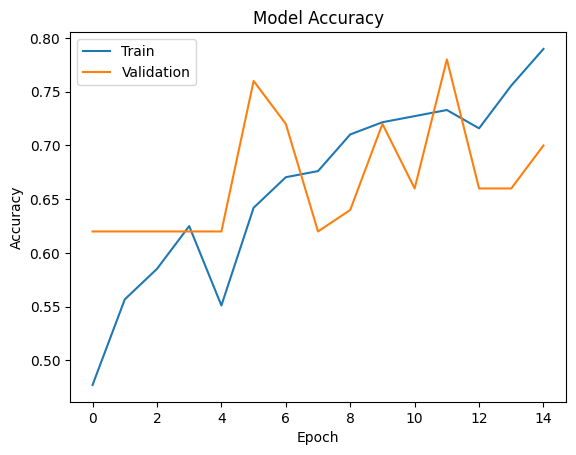

In [69]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_best_trial.history['accuracy'])
plt.plot(history_best_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

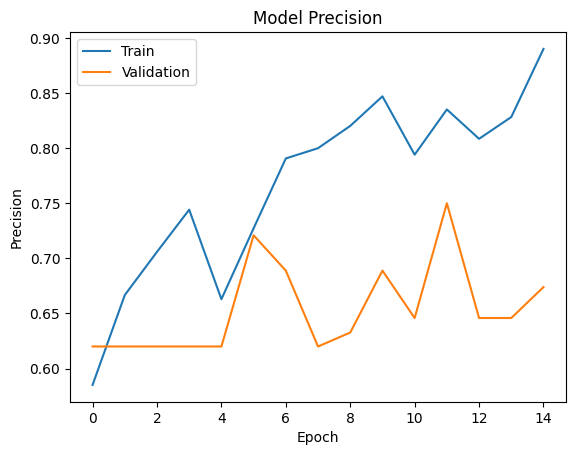

In [62]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history_best_trial.history['precision'])
plt.plot(history_best_trial.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

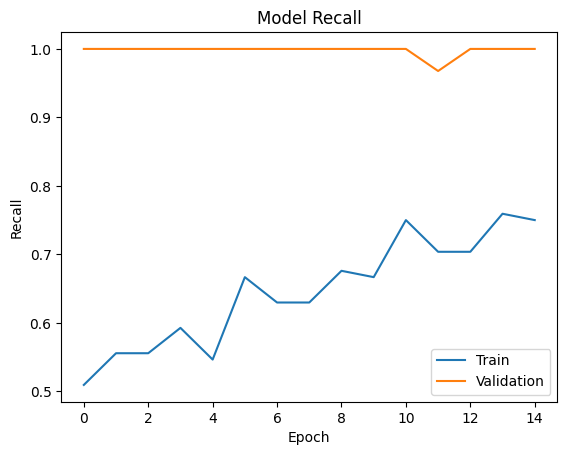

In [63]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history_best_trial.history['recall'])
plt.plot(history_best_trial.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

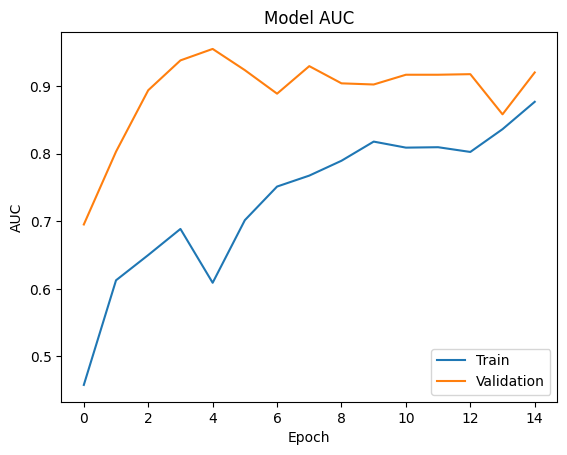

In [64]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history_best_trial.history['auc'])
plt.plot(history_best_trial.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

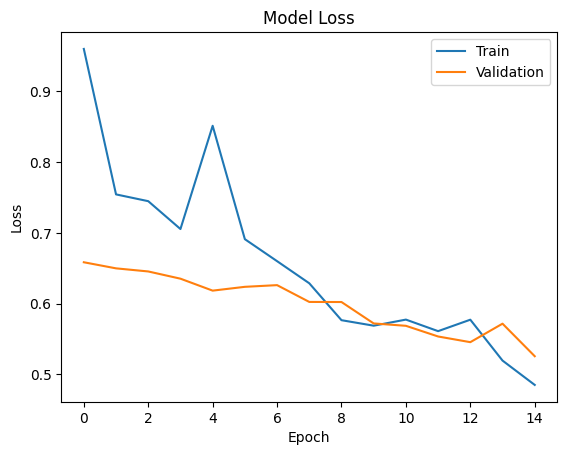

In [74]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_best_trial.history['loss'])
plt.plot(history_best_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [66]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_best_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step

Prediction Probability:
[[0.57938296]]

Predicted Class:
yes


In [67]:
image_path = "sample-yes.JPG"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_best_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Prediction Probability:
[[0.6481864]]

Predicted Class:
yes


In [70]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# WITH STABLE TRIAL METRIC
# =========================================================
params = study.trials[10].params
print("Params ==> ", params)
trainable = params['trainable']
layers_trainable = params['layers_trainable']
dropout_rate = params['droprate']
n_dense = params['n_dense']
lr = params['learning_rate']

base_model_stable_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_stable_trial.trainable = trainable
if trainable:
  for layer in base_model_stable_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_stable_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_stable_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_stable_trial = base_model_stable_trial(input_stable_trial, training=False)
x_stable_trial = layers.GlobalAveragePooling2D()(x_stable_trial)
x_stable_trial = layers.BatchNormalization()(x_stable_trial)
x_stable_trial = layers.Dropout(dropout_rate)(x_stable_trial)

for i in range(n_dense):
  dense_unit = params[f'dense_unit_{i}']
  dense_dropout = params[f'dense_droprate_{i}']
  x_stable_trial = layers.Dense(dense_unit, activation='relu')(x_stable_trial)
  x_stable_trial = layers.BatchNormalization()(x_stable_trial)
  x_stable_trial = layers.Dropout(dense_dropout)(x_stable_trial)

output_stable_trial = layers.Dense(1, activation='sigmoid')(x_stable_trial)
model_stable_trial = models.Model(input_stable_trial, output_stable_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_stable_trial.compile(
  optimizer=model_opt,
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model_stable_trial.summary()

Params ==>  {'trainable': True, 'layers_trainable': 25, 'droprate': 0.25, 'n_dense': 1, 'learning_rate': 1.0129398960755136e-05, 'dense_unit_0': 512, 'dense_droprate_0': 0.30000000000000004}


Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_97 (InputLayer)     │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_48     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_138         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_138 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_139         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_139 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,981,953 (57.15 MB)

 Trainable params: 14,979,905 (57.14 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [71]:
# =========================================================
# MODEL FIT WITH STABLE METRIC TRIAL
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
  tf.keras.callbacks.ModelCheckpoint('./stable_trial_best_model.h5', monitor='val_auc', save_best_only=True, mode='max')
]

history_stable_trial = model_stable_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

validation_data.reset()
y_prob = model_stable_trial.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5912 - auc: 0.5602 - loss: 0.8815 - precision: 0.7810 - recall: 0.5200

11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5739 - auc: 0.5750 - loss: 0.8365 - precision: 0.6988 - recall: 0.5370 - val_accuracy: 0.3800 - val_auc: 0.6919 - val_loss: 0.8850 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0129e-05
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6829 - auc: 0.7313 - loss: 0.6833 - precision: 0.7127 - recall: 0.7139

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7045 - auc: 0.7549 - loss: 0.6609 - precision: 0.7917 - recall: 0.7037 - val_accuracy: 0.3800 - val_auc: 0.8200 - val_loss: 0.8638 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0129e-05
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6846 - auc: 0.7246 - loss: 0.7426 - precision: 0.8071 - recall: 0.6525

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 482ms/step - accuracy: 0.7159 - auc: 0.7915 - loss: 0.6130 - precision: 0.8295 - recall: 0.6759 - val_accuracy: 0.3800 - val_auc: 0.8574 - val_loss: 0.8570 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0129e-05
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.6426 - auc: 0.7225 - loss: 0.6729 - precision: 0.7309 - recall: 0.6485

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7102 - auc: 0.7853 - loss: 0.6067 - precision: 0.8000 - recall: 0.7037 - val_accuracy: 0.3800 - val_auc: 0.8879 - val_loss: 0.8387 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0129e-05
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8158 - auc: 0.9161 - loss: 0.3695 - precision: 0.8628 - recall: 0.7991

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8466 - auc: 0.9561 - loss: 0.2912 - precision: 0.9263 - recall: 0.8148 - val_accuracy: 0.8200 - val_auc: 0.9660 - val_loss: 0.5655 - val_precision: 1.0000 - val_recall: 0.7097 - learning_rate: 1.0129e-05
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9180 - auc: 0.9848 - loss: 0.2201 - precision: 0.9807 - recall: 0.8890

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 928ms/step - accuracy: 0.9034 - auc: 0.9598 - loss: 0.2643 - precision: 0.9417 - recall: 0.8981 - val_accuracy: 0.8400 - val_auc: 0.9694 - val_loss: 0.5354 - val_precision: 1.0000 - val_recall: 0.7419 - learning_rate: 1.0129e-05
Epoch 16/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8624 - auc: 0.9584 - loss: 0.2965 - precision: 0.9430 - recall: 0.8239

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8523 - auc: 0.9514 - loss: 0.3278 - precision: 0.9457 - recall: 0.8056 - val_accuracy: 0.8600 - val_auc: 0.9711 - val_loss: 0.5130 - val_precision: 1.0000 - val_recall: 0.7742 - learning_rate: 1.0129e-05
Epoch 17/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step - accuracy: 0.8807 - auc: 0.9531 - loss: 0.2801 - precision: 0.9223 - recall: 0.8796 - val_accuracy: 0.8600 - val_auc: 0.9694 - val_loss: 0.4866 - val_precision: 0.9615 - val_recall: 0.8065 - learning_rate: 1.0129e-05
Epoch 18/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 380ms/step - accuracy: 0.8693 - auc: 0.9460 - loss: 0.3125 - precision: 0.9208 - recall: 0.8611 - val_accuracy: 0.8600 - val_auc: 0.9559 - val_loss: 0.4581 - val_precision: 0.8750 - val_recall: 0.9032 - learning_rate: 1.0129e-05
Epoch 19/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.8523 - auc: 0.9308 - loss: 0.3539 - precision: 0.9184 - recall: 0.8333 - val_accuracy: 0.8600 - val_auc: 0.9550 - val_loss: 0.4696 

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9375 - auc: 0.9887 - loss: 0.1798 - precision: 0.9802 - recall: 0.9167 - val_accuracy: 0.8400 - val_auc: 0.9745 - val_loss: 0.4163 - val_precision: 0.9600 - val_recall: 0.7742 - learning_rate: 1.0129e-05
Epoch 23/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.8977 - auc: 0.9789 - loss: 0.2241 - precision: 0.9592 - recall: 0.8704 - val_accuracy: 0.9400 - val_auc: 0.9745 - val_loss: 0.3933 - val_precision: 0.9667 - val_recall: 0.9355 - learning_rate: 1.0129e-05
Epoch 24/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9194 - auc: 0.9816 - loss: 0.1800 - precision: 0.9601 - recall: 0.9103

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 480ms/step - accuracy: 0.9432 - auc: 0.9930 - loss: 0.1547 - precision: 0.9804 - recall: 0.9259 - val_accuracy: 0.9200 - val_auc: 0.9779 - val_loss: 0.3820 - val_precision: 0.9655 - val_recall: 0.9032 - learning_rate: 1.0129e-05
Epoch 25/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 374ms/step - accuracy: 0.9148 - auc: 0.9764 - loss: 0.2461 - precision: 0.9794 - recall: 0.8796 - val_accuracy: 0.9200 - val_auc: 0.9754 - val_loss: 0.3585 - val_precision: 0.9355 - val_recall: 0.9355 - learning_rate: 1.0129e-05
Epoch 26/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 0.9545 - auc: 0.9873 - loss: 0.1703 - precision: 0.9808 - recall: 0.9444 - val_accuracy: 0.9200 - val_auc: 0.9711 - val_loss: 0.3332 - val_precision: 0.9355 - val_recall: 0.9355 - learning_rate: 1.0129e-05
Epoch 27/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - accuracy: 0.9375 - auc: 0.9902 - loss: 0.1630 - precision: 0.9619 - recall: 0.9352 - val_accuracy: 0.9200 - val_auc: 0.9660 - val_loss: 0.311

In [75]:
test_data.reset()
loss, accuracy, auc, precision, recall = model_stable_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8519 - auc: 1.0000 - loss: 0.3609 - precision: 1.0000 - recall: 0.7500

Test Accuracy: 0.8518518805503845
Test Precision: 1.0
Test Recall: 1.0
Test AUC: 0.75
Test Loss: 0.36091989278793335


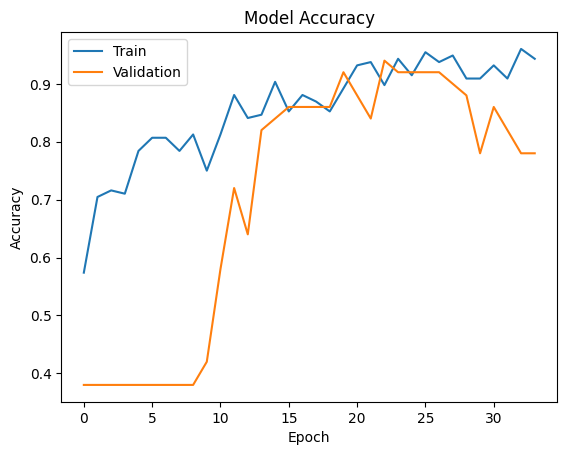

In [76]:
# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_stable_trial.history['accuracy'])
plt.plot(history_stable_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

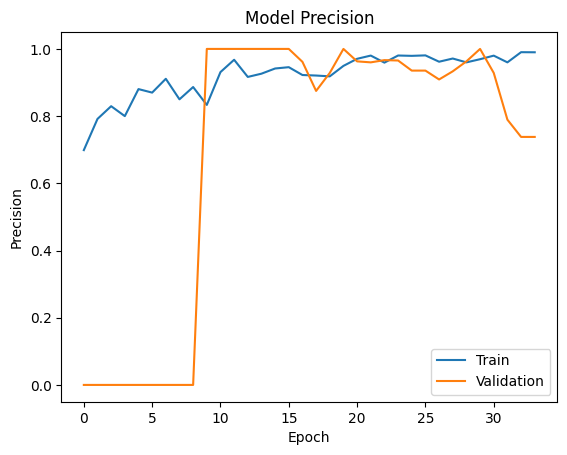

In [77]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history_stable_trial.history['precision'])
plt.plot(history_stable_trial.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

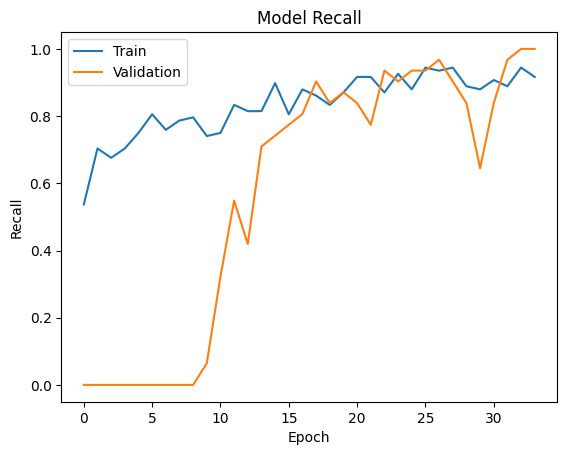

In [78]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history_stable_trial.history['recall'])
plt.plot(history_stable_trial.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

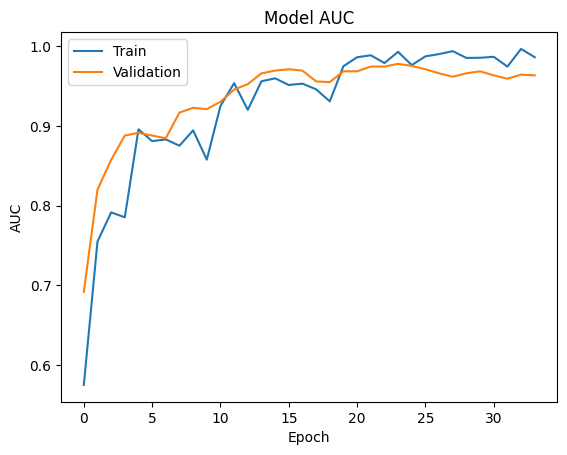

In [79]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history_stable_trial.history['auc'])
plt.plot(history_stable_trial.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

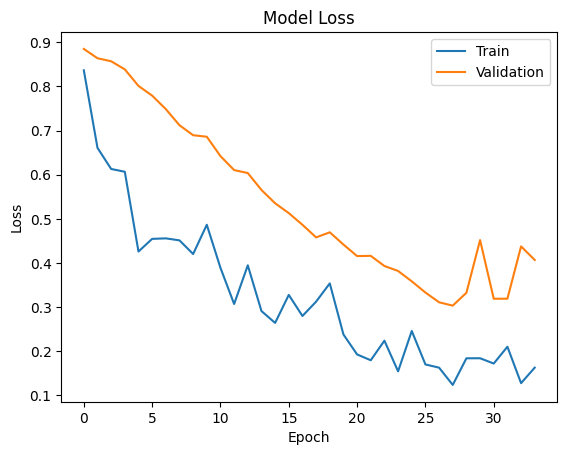

In [80]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_stable_trial.history['loss'])
plt.plot(history_stable_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [81]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_stable_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step

Prediction Probability:
[[0.37033126]]

Predicted Class:
no


In [82]:
image_path = "sample-yes.JPG"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_stable_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Prediction Probability:
[[0.47222888]]

Predicted Class:
no
